In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append(str(Path.cwd().parent))
from src.config import INTERIM_DIR

aligned_headline = pd.read_parquet(INTERIM_DIR / 'aligned_headlines.parquet')
aligned_headline.head()

,ticker,published_at,headline,url,published_eastern_time,target_date,day,open_to_close,label
0,AAPL,2026-01-20 20:31:08+00:00,Bill Gates Recalls Warren Buffett Treating Him...,https://finance.yahoo.com/news/bill-gates-reca...,2026-01-20 15:31:08-05:00,2026-01-21,2026-01-21,-0.004222,0
1,AAPL,2026-01-21 09:29:42+00:00,Chainlink Enables 24/5 On-Chain Trading for St...,https://finance.yahoo.com/news/chainlink-enabl...,2026-01-21 04:29:42-05:00,2026-01-21,2026-01-21,-0.004222,0
2,AAPL,2026-01-21 09:34:00+00:00,"The Zacks Analyst Blog Highlights Apple, Walma...",https://finance.yahoo.com/news/zacks-analyst-b...,2026-01-21 04:34:00-05:00,2026-01-21,2026-01-21,-0.004222,0
3,AAPL,2026-01-21 10:12:03+00:00,Netflix defends Warner Bros bid as shares drop...,https://finance.yahoo.com/news/netflix-defends...,2026-01-21 05:12:03-05:00,2026-01-21,2026-01-21,-0.004222,0
4,AAPL,2026-01-21 10:15:00+00:00,Smart TV Sticks Market Set to Reach USD 57.08 ...,https://www.globenewswire.com/news-release/202...,2026-01-21 05:15:00-05:00,2026-01-21,2026-01-21,-0.004222,0


In [2]:
# Class balance check
counts = aligned_headline['label'].value_counts()
print(counts)
print()
print('Up %:', round(100 * counts[1] / len(aligned_headline), 2)) # Percent baseline that must be beat

label
0    8978
1    8918
Name: count, dtype: int64

Up %: 49.83


count    171.000000
mean     104.654971
std       63.925722
min        9.000000
25%       59.500000
50%       86.000000
75%      128.000000
max      358.000000
dtype: float64



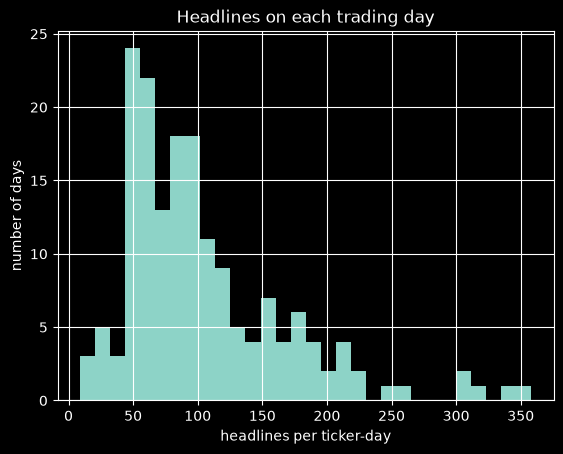

In [4]:
# Headlines per trading day
per_day = aligned_headline.groupby(['ticker', 'day']).size()
print(per_day.describe())
print()
per_day.hist(bins=30)
plt.xlabel('headlines per ticker-day')
plt.ylabel('number of days')
plt.title('Headlines on each trading day')
plt.show()

#### Observations
- The median is 86 thus there are 86 headlines per trading day and the 25th percentile shows at least 60 headlines
- Min is 9 and max is 358 in a ticker day
- Distribution is right skewed
- Might have to do aggregations into one feature later since there are multiple headlines per trading day

In [5]:
# Headline length and samples
aligned_headline['word_count'] = aligned_headline['headline'].str.split().str.len()
print(aligned_headline['word_count'].describe())
print()
for headline in aligned_headline['headline'].sample(8, random_state=1):
    print('-', headline)


count    17896.000000
mean        12.363880
std          4.284937
min          2.000000
25%          9.000000
50%         12.000000
75%         15.000000
max         44.000000
Name: word_count, dtype: float64

- Nvidia hits historic valuation milestone with record market cap
- Morgan Stanley survey shows record upgrade interest for Apple’s iPhones
- Fed News and Big Tech Earnings Collide This Week. The Mag 7 Matter Most.
- QQQY Flips Nasdaq Volatility Into a 45% Yield, Paid Weekly! It’s Hard To Process
- Satya Nadella Has Positioned Microsoft to Grow. Investors Are Missing the Point.
- Alphabet Stock Joins the Dow but It’s Rising for a Different Reason
- Tech stocks today: Meta, Google stocks little changed after social media verdict, OpenAI shuts down Sora
- David Rolfe's Strategic Moves: Chubb Ltd Takes Center Stage with 3.29% Portfolio Share


#### Observations
- Average headline length is 12 words with a max of 44 words
- No preprocessing of headlines needed